Setup complete. NumPy 2.0.2
scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 2, 2)
A:
 [[0 1 2]
 [3 4 5]]
A + B (element-wise add):
 [[1 2 3]
 [4 5 6]]
A.T (transpose -> shape (3, 2) ):
 [[0 3]
 [1 4]
 [2 5]]
A.reshape(3, 2):
 [[0 1]
 [2 3]
 [4 5]]
A.flatten(): [0 1 2 3 4 5]
T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
T ndim: 2
T shape: (3, 4)
T + T:
 [[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]
T.T shape: (4, 3)
T reshaped to (2, 6):
 [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]
a . b (dot): 7
a x b (cross): [ 2 11 -8]
L2 norm ||a||_2: 3.7416573867739413
L1 norm ||a||_1: 6.0
Linf norm: 3.0
cosine(a, b): 0.454
Pair 1:
L1 norm: 2.0
L2 norm: 1.4142135623730951
Cosine similarity: 1.0
Pair 2:
L1 norm: 6.0
L2 norm: 3.7416573867739413
Cosine similarity: 0.714
Pair 3:
L1 norm: 2.0
L2 norm: 2.0
Cosine similarity: 0.0
Most similar pair = 1
A @ B (matrix multiply):
 [[ 6.  2.]
 [13.  6.]]
A.T (transpose):
 [[2. 1.]
 [1. 3.]]
inverse(

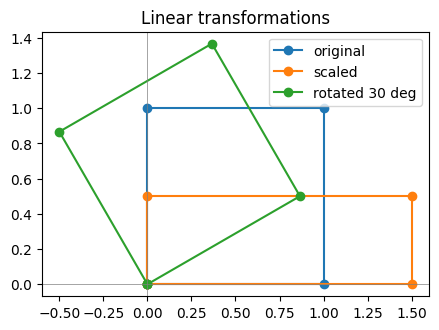

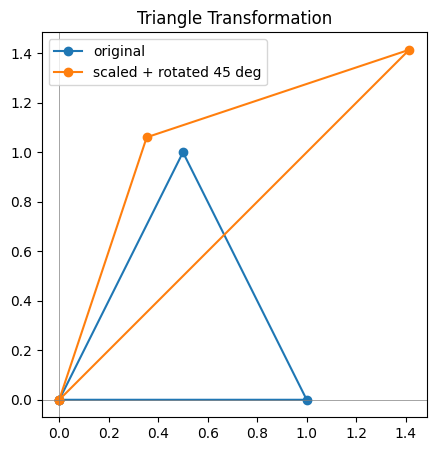

Eigenvalues (lambda): [2. 3.]
Eigenvectors (columns):
 [[1. 0.]
 [0. 1.]]
lambda=2.0  A v == lambda v ? True
lambda=3.0  A v == lambda v ? True
Eigenvalues: [5. 2.]
Eigenvectors (columns):
 [[ 0.707 -0.447]
 [ 0.707  0.894]]
C @ v: [3.536 3.536]
lambda * v: [3.536 3.536]
Verification: True
Solution x: [ 2.  3. -1.]
Rank of A: 3
Full rank -> a unique solution exists
Rank of D: 2 -> < 3, so rows are dependent
cosine(king, queen): 0.986
cosine(king, apple): 0.267
Solution x: [1. 2.]
Rank of A2: 2
cosine(cat, dog): 0.995
cosine(cat, car): 0.293
cat is more similar to dog.


In [2]:

# ============================================================
# NUMPY LINEAR ALGEBRA LAB
# ============================================================

# ------------------------------------------------------------
# CORE IMPORTS FOR THE WHOLE LAB
# ------------------------------------------------------------

import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
np.random.seed(42)

print("Setup complete. NumPy", np.__version__)


# ============================================================
# 1. SCALARS, VECTORS, MATRICES & TENSORS
# ============================================================

# ------------------------------------------------------------
# 1A. THE FOUR CONTAINERS
# ------------------------------------------------------------

scalar = np.array(5)                  # 0-D: a single number
vector = np.array([2, 5, 1])          # 1-D: a list of numbers
matrix = np.array([[1, 2], [3, 4]])   # 2-D: rows x columns
tensor = np.ones((3, 2, 2))           # n-D: a stack of matrices

# .ndim = number of dimensions
# .shape = size along each dimension

for name, arr in [
    ("scalar", scalar),
    ("vector", vector),
    ("matrix", matrix),
    ("tensor", tensor)
]:
    print(f"{name:7s} ndim={arr.ndim}  shape={arr.shape}")


# ------------------------------------------------------------
# 1B. TENSOR OPERATIONS: ADD, TRANSPOSE, RESHAPE
# ------------------------------------------------------------

A = np.arange(6).reshape(2, 3)
B = np.ones((2, 3), dtype=int)

print("A:\n", A)
print("A + B (element-wise add):\n", A + B)
print("A.T (transpose -> shape", A.T.shape, "):\n", A.T)
print("A.reshape(3, 2):\n", A.reshape(3, 2))
print("A.flatten():", A.flatten())


# ------------------------------------------------------------
# LAB EXERCISE 1 — TENSOR OPS
# ------------------------------------------------------------

T = np.arange(12).reshape(3, 4)

print("T:\n", T)

# 1. ndim and shape
print("T ndim:", T.ndim)
print("T shape:", T.shape)

# 2. T + T
print("T + T:\n", T + T)

# 3. Transpose and reshape
print("T.T shape:", T.T.shape)
print("T reshaped to (2, 6):\n", T.reshape(2, 6))


# ============================================================
# 2. DOT & CROSS PRODUCTS, AND NORMS
# ============================================================

# ------------------------------------------------------------
# 2A. DOT & CROSS PRODUCTS
# ------------------------------------------------------------

a = np.array([1, 2, 3])
b = np.array([4, 0, 1])

# Dot product
print("a . b (dot):", np.dot(a, b))

# Cross product
print("a x b (cross):", np.cross(a, b))


# ------------------------------------------------------------
# 2B. NORMS + COSINE SIMILARITY
# ------------------------------------------------------------

print("L2 norm ||a||_2:", la.norm(a))
print("L1 norm ||a||_1:", la.norm(a, 1))
print("Linf norm:", la.norm(a, np.inf))


def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))


print("cosine(a, b):", round(cosine(a, b), 3))


# ------------------------------------------------------------
# LAB EXERCISE 2 — L1/L2 NORMS + COSINE SIMILARITY
# ------------------------------------------------------------

pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),  # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),  # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0]))   # pair 3
]

similarities = []

for i, (u, v) in enumerate(pairs, start=1):

    # 1. L1 and L2 norm of u
    l1 = la.norm(u, 1)
    l2 = la.norm(u)

    # 2. Cosine similarity of u and v
    sim = cosine(u, v)
    similarities.append(sim)

    print(f"Pair {i}:")
    print("L1 norm:", l1)
    print("L2 norm:", l2)
    print("Cosine similarity:", round(sim, 3))

# 3. Most similar pair
most_similar = np.argmax(similarities) + 1
print("Most similar pair =", most_similar)

# Answer: Pair 1


# ============================================================
# 3. MATRIX OPERATIONS & SPECIAL MATRICES
# ============================================================

# ------------------------------------------------------------
# 3A. CORE MATRIX OPERATIONS
# ------------------------------------------------------------

A = np.array([
    [2., 1.],
    [1., 3.]
])

B = np.array([
    [1., 0.],
    [4., 2.]
])

print("A @ B (matrix multiply):\n", A @ B)
print("A.T (transpose):\n", A.T)
print("inverse(A):\n", la.inv(A))
print("trace(A) = sum of diagonal:", np.trace(A))


# ------------------------------------------------------------
# 3B. SPECIAL MATRICES: IDENTITY, SYMMETRIC, ORTHOGONAL
# ------------------------------------------------------------

I = np.eye(2)

print("Identity I:\n", I)
print("A @ inv(A) == I ?", np.allclose(A @ la.inv(A), I))

# Symmetric matrix
print("A symmetric?", np.allclose(A, A.T))

# Orthogonal matrix
theta = np.radians(30)

Q = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])

print("Q orthogonal?", np.allclose(Q.T @ Q, I))


# ------------------------------------------------------------
# LAB EXERCISE 3 — INVERSE, TRACE, AND MATRIX TESTS
# ------------------------------------------------------------

M = np.array([
    [4., 2.],
    [2., 3.]
])

P = np.array([
    [0., -1.],
    [1.,  0.]
])

# 1. Inverse and trace of M
M_inv = la.inv(M)

print("Inverse of M:\n", M_inv)
print("Trace of M:", np.trace(M))

# 2. M @ inv(M) == I
I = np.eye(M.shape[0])

print("M @ inv(M):\n", M @ M_inv)
print("M @ inv(M) == I ?", np.allclose(M @ M_inv, I))

# 3. Is M symmetric? Is P orthogonal?
print("M symmetric?", np.allclose(M, M.T))
print("P orthogonal?", np.allclose(P.T @ P, I))


# ============================================================
# 4. TRANSFORMATIONS: ROTATION & SCALING
# ============================================================

# ------------------------------------------------------------
# 4A. BUILD TRANSFORMATION MATRICES
# ------------------------------------------------------------

# A unit square defined by its 4 corners
# Each column is a point

square = np.array([
    [0, 1, 1, 0],
    [0, 0, 1, 1]
], dtype=float)

# Scaling matrix: stretch x by 1.5, y by 0.5
S = np.array([
    [1.5, 0.0],
    [0.0, 0.5]
])

# Rotation matrix: rotate by 30 degrees
t = np.radians(30)

R = np.array([
    [np.cos(t), -np.sin(t)],
    [np.sin(t), np.cos(t)]
])

scaled = S @ square
rotated = R @ square

print("Rotated corners:\n", rotated)


# ------------------------------------------------------------
# 4B. PLOT ORIGINAL VS TRANSFORMED
# ------------------------------------------------------------

def close_loop(pts):
    # Repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])


fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(*close_loop(square), marker="o", label="original")
ax.plot(*close_loop(scaled), marker="o", label="scaled")
ax.plot(*close_loop(rotated), marker="o", label="rotated 30 deg")

ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)

ax.set_aspect("equal")
ax.legend()
ax.set_title("Linear transformations")

plt.show()


# ------------------------------------------------------------
# LAB EXERCISE 4 — APPLY 2 TRANSFORMATIONS & PLOT
# ------------------------------------------------------------

tri = np.array([
    [0, 1, 0.5],
    [0, 0, 1.0]
], dtype=float)

# 1. Scaling matrix: x * 2, y * 0.5
S_tri = np.array([
    [2.0, 0.0],
    [0.0, 0.5]
])

# 2. Rotation matrix for 45 degrees
angle = np.radians(45)

R_tri = np.array([
    [np.cos(angle), -np.sin(angle)],
    [np.sin(angle), np.cos(angle)]
])

# 3. Apply scaling first, then rotation
scaled_tri = S_tri @ tri
transformed_tri = R_tri @ scaled_tri

# Plot original and transformed triangle
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(
    *close_loop(tri),
    marker="o",
    label="original"
)

ax.plot(
    *close_loop(transformed_tri),
    marker="o",
    label="scaled + rotated 45 deg"
)

ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)

ax.set_aspect("equal")
ax.legend()
ax.set_title("Triangle Transformation")

plt.show()


# ============================================================
# 5. EIGENVALUES & EIGENVECTORS
# ============================================================

# For a matrix A:
# A v = lambda v


# ------------------------------------------------------------
# 5A. COMPUTE EIGENVALUES & EIGENVECTORS
# ------------------------------------------------------------

A = np.array([
    [2., 0.],
    [0., 3.]
])

vals, vecs = la.eig(A)

# vals = eigenvalues
# vecs columns = eigenvectors

print("Eigenvalues (lambda):", vals)
print("Eigenvectors (columns):\n", vecs)


# ------------------------------------------------------------
# 5B. VERIFY A v = lambda v
# ------------------------------------------------------------

for i in range(len(vals)):

    v = vecs[:, i]

    lhs = A @ v
    rhs = vals[i] * v

    print(
        f"lambda={vals[i]:.1f}  "
        f"A v == lambda v ?",
        np.allclose(lhs, rhs)
    )


# ------------------------------------------------------------
# LAB EXERCISE 5 — EIGENVALUES/VECTORS & VERIFICATION
# ------------------------------------------------------------

C = np.array([
    [4., 1.],
    [2., 3.]
])

# 1. Compute eigenvalues and eigenvectors
vals_C, vecs_C = la.eig(C)

# 2. Print eigenvalues
print("Eigenvalues:", vals_C)
print("Eigenvectors (columns):\n", vecs_C)

# 3. Verify C @ v == lambda * v
# for the first eigenvector

v = vecs_C[:, 0]

lhs = C @ v
rhs = vals_C[0] * v

print("C @ v:", lhs)
print("lambda * v:", rhs)
print("Verification:", np.allclose(lhs, rhs))


# ============================================================
# 6. RANK, SOLVING SYSTEMS & COSINE SIMILARITY
# ============================================================

# ------------------------------------------------------------
# 6A. SOLVE A 3x3 SYSTEM A x = b
# ------------------------------------------------------------

A = np.array([
    [2., 1., -1.],
    [-3., -1., 2.],
    [-2., 1., 2.]
])

b = np.array([8., -11., -3.])

x = la.solve(A, b)

print("Solution x:", x)
# Expected: [2, 3, -1]

print("Rank of A:", la.matrix_rank(A))
# 3 -> full rank

print("Full rank -> a unique solution exists")


# ------------------------------------------------------------
# 6B. RANK TELLS YOU SOLVABILITY
# ------------------------------------------------------------

# A rank-deficient matrix:
# row 3 = row 1 + row 2

D = np.array([
    [1., 2., 3.],
    [4., 5., 6.],
    [5., 7., 9.]
])

print(
    "Rank of D:",
    la.matrix_rank(D),
    "-> < 3, so rows are dependent"
)


# ------------------------------------------------------------
# 6C. COSINE SIMILARITY ON 'EMBEDDINGS'
# ------------------------------------------------------------

# Toy 4-D embeddings

king = np.array([0.8, 0.6, 0.1, 0.2])
queen = np.array([0.7, 0.7, 0.1, 0.3])
apple = np.array([0.1, 0.0, 0.9, 0.8])

print(
    "cosine(king, queen):",
    round(cosine(king, queen), 3)
)

print(
    "cosine(king, apple):",
    round(cosine(king, apple), 3)
)


# ------------------------------------------------------------
# LAB EXERCISE 6 — SOLVE A SYSTEM + COMPARE EMBEDDINGS
# ------------------------------------------------------------

A2 = np.array([
    [3., 2.],
    [1., 4.]
])

b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

# 1. Solve A2 x = b2
x2 = la.solve(A2, b2)

print("Solution x:", x2)

# 2. Rank of A2
rank_A2 = la.matrix_rank(A2)

print("Rank of A2:", rank_A2)

# 3. Cosine similarity of cat and dog
cat_dog = cosine(cat, dog)

# 4. Cosine similarity of cat and car
cat_car = cosine(cat, car)

print("cosine(cat, dog):", round(cat_dog, 3))
print("cosine(cat, car):", round(cat_car, 3))

# 5. Which is more similar?
if cat_dog > cat_car:
    print("cat is more similar to dog.")
else:
    print("cat is more similar to car.")